### pyAPES_MLM: Multi-layer soil-vegetation-atmosphere transfer model

Demo how to:
1. Set-up the model
1. Run the model
1. Retrieve the results using xarray

In [19]:
# setting path
import sys
import os

from dotenv import load_dotenv
load_dotenv()
pyAPES_main_folder = os.getenv('pyAPES_main_folder')
sys.path.append(pyAPES_main_folder)
os.chdir(pyAPES_main_folder)

In [20]:
from pyAPES.parameters.parameter_tools import get_parameter_list
tasks = get_parameter_list(params, 'degero_snow')

NameError: name 'params' is not defined

### Import modules

In [2]:
from pyAPES.utils.iotools import read_results
import matplotlib.pyplot as plt

resultfile = 'results/202605221200_degero_snow.nc'
# read simulation restuls to xarray dataset
results = read_results(resultfile)

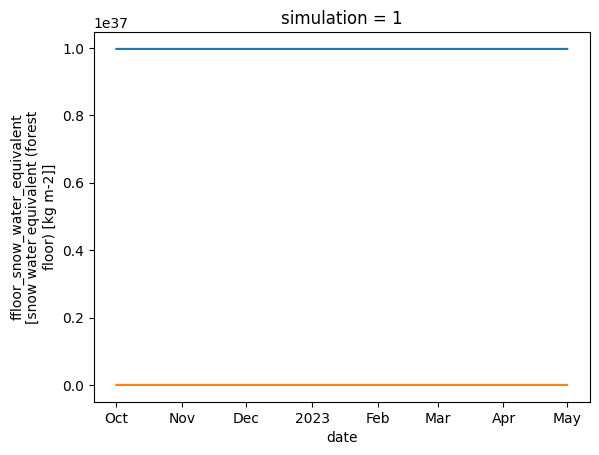

In [3]:
plt.figure()
for simu in [0,1]:
    results['ffloor_snow_water_equivalent'].sel(simulation=simu).plot()

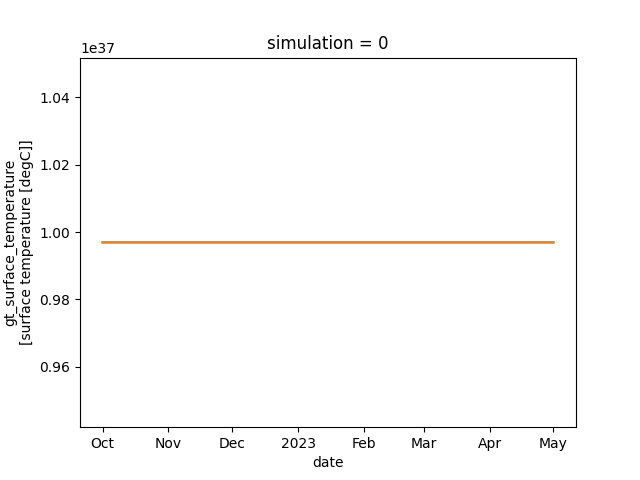

In [4]:
%matplotlib widget
plt.figure()
results['soil_temperature'][:,0,0].plot()
results['gt_surface_temperature'][:,0,0].plot()
#results['gt_temperature'][:,0,0].plot()
#results['canopy_temperature'][:,0,0].plot()

### Print resuts metadata:

Output variables are those defined at pyAPES.parameters.mlm_outputs'. Each variable contains one or several of following dimensions:

- date --> time dimension
- simulation --> simulation number. If there is only one, remember that it has index 0!
- canopy --> canopy and air layers. Index is 0 at ground and increases upwards
- planttype --> planttypes defined in mlm_parameters. Index follows the order in dict cpara['planttypes']) 
- soil -> soil layers. Index 0 is at the top and increases downwards (nr soil layers, 0 at top)
- groundtype --> groundtypes at forestfloor. Defined in mlm_parameters. Index follows the order in dict: cpara['forestfloor']['bottom_layer_types']


In [5]:
print(results)

# print list of all variables:
#vars = list(results.data_vars)
#for v in vars:
#    print(v)

<xarray.Dataset> Size: 165MB
Dimensions:                               (date: 10177, simulation: 2,
                                           canopy: 20, planttype: 2, soil: 44,
                                           groundtype: 1)
Coordinates:
  * date                                  (date) datetime64[ns] 81kB 2022-10-...
  * simulation                            (simulation) int64 16B 0 1
  * canopy                                (canopy) float32 80B 9.969e+36 ... ...
  * soil                                  (soil) float32 176B 9.969e+36 ... 9...
Dimensions without coordinates: planttype, groundtype
Data variables: (12/166)
    forcing_air_temperature               (date, simulation) float32 81kB ...
    forcing_precipitation                 (date, simulation) float32 81kB ...
    forcing_pressure                      (date, simulation) float32 81kB ...
    forcing_h2o                           (date, simulation) float32 81kB ...
    forcing_co2                           (date

### Plot some model results

In [6]:
sim = 0  # in this demo, we have only one simulation (i.e. only one parameter set was used)

# grid variables for plotting
t = results.date  # time
zc = results.canopy_z  # height above ground [m]
zs = results.soil_z  # depth of soil; shown negative [m]

### Soil temperature and moisture

- computed using pyAPES.soil - package submodels 'Water' and 'Heat'
- model state at end of simulation is in: Model.soil.heat & Model.soil.water

In [7]:
# model state (last timestep)

#soilheat = Model.soil.heat
#vars(soilheat)  # list instance variables

#soilwater = Model.soil.water
#vars(soilwater) 

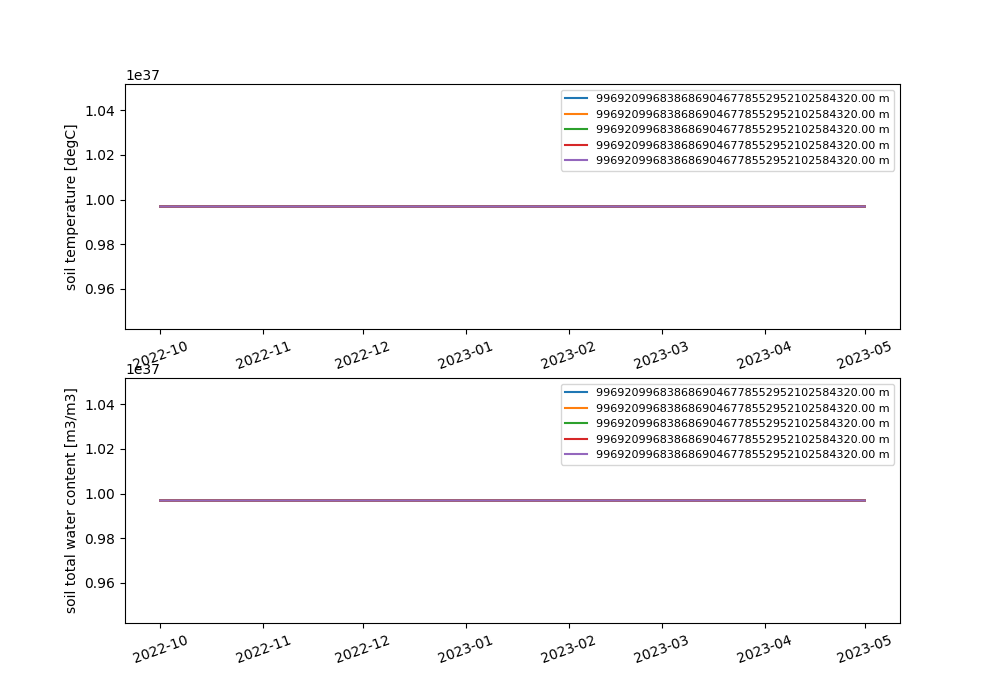

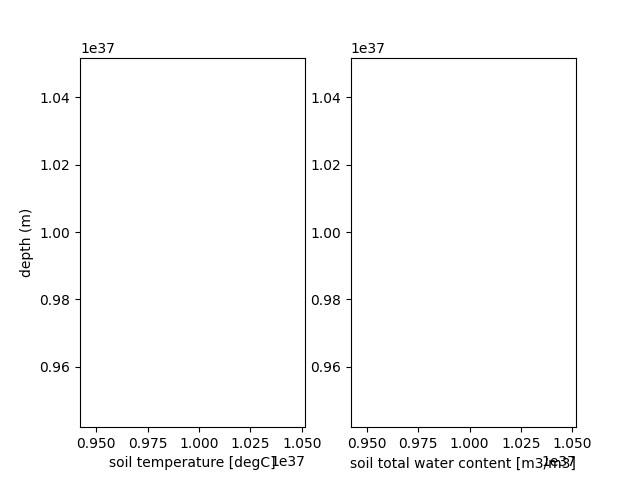

In [8]:
import numpy as np
var = ['soil_temperature', 'soil_volumetric_water_content']

lyrs = [0, 1, 2, 3, 4] # five top layers
#depths = np.array2string(np.asarray(zs[lyrs]), precision=1, separator=', ')
depths = ['{:.2f} m'.format(k) for k in zs[lyrs]]

fig, ax = plt.subplots(2, 1, figsize=(10,7))

k = 0
for v in var:
    ax[k].plot(t, results[v][:,sim,lyrs], label=depths)
    ax[k].set_ylabel(results[v].attrs['units'])
    ax[k].tick_params(axis='x', labelrotation = 20)
    ax[k].legend(fontsize=8)
    k += 1

# vertical profile at last timestep
fig, ax = plt.subplots(1, 2) #figsize=(10,5))

k = 0
for v in var:
    ax[k].plot(results[v][-1,sim,:], zs)
    ax[k].set_xlabel(results[v].attrs['units'])
    ax[0].set_ylabel('depth (m)')
    k += 1

### Ecosystem-scale fluxes

- ecosystem - atm. fluxes represent the integrated sinks / sources in soil (soil-module), forestfloor (bottomlayer-module) and vegetation (planttype&canopy -modules)
- comparable to ecosystem - atmosphere exchange
- affected by current model forcing and sub-model instance state (e.g. Planttype and Canopy LAI, phenology, soil temperature, moisture etc.)


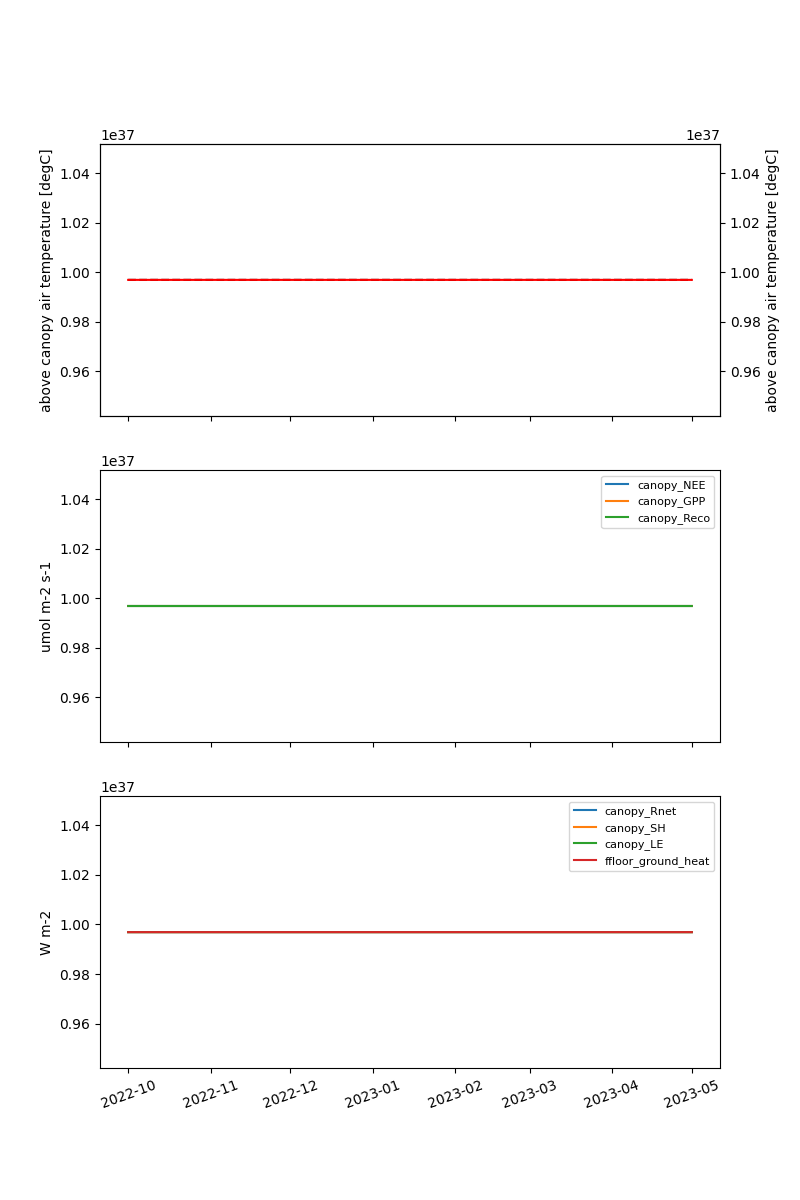

In [9]:

var = ['forcing_air_temperature', 'forcing_par', 'canopy_NEE', 'canopy_GPP', 
       'canopy_Reco', 'canopy_Rnet', 'canopy_SH', 'canopy_LE', 'ffloor_ground_heat']

fig, ax = plt.subplots(3, 1, figsize=(8,12), sharex=True)

# temperature & par
ax[0].plot(t, results[var[0]][:,sim], 'k--', label=var[0])
ax[0].set_ylabel(results[var[0]].attrs['units'])
ax[0].tick_params(axis='x', labelrotation = 20)
axb = ax[0].twinx()

axb.plot(t, results[var[1]][:,sim], 'r-', label=var[1]) # Par
axb.set_ylabel(results[var[0]].attrs['units'])

# CO2 fluxes
for v in var[2:5]:
    ax[1].plot(t, results[v][:,sim], label=v)

ax[1].set_ylabel('umol m-2 s-1')
ax[1].tick_params(axis='x', labelrotation = 20)
ax[1].legend(fontsize=8)

# energy fluxes
for v in var[5:]:
    ax[2].plot(t, results[v][:,sim], label=v)

ax[2].set_ylabel('W m-2')
ax[2].tick_params(axis='x', labelrotation = 20)
ax[2].legend(fontsize=8)



### Ecosystem radiation balance

- net radiation (Rnet) is the sum of net shortwave (SWnet = incoming - reflected) and net longwave (LWnet = incoming - emitted) radiation at canopy top
- computed via models in pyAPES.microclimate.radiation, called iteratively from pyAPES.canopy.mlm_canopy to account for canopy structure and leaf & forest floor temperature
- ecosystem albedo can be computed from radiation profiles at uppermost grid point

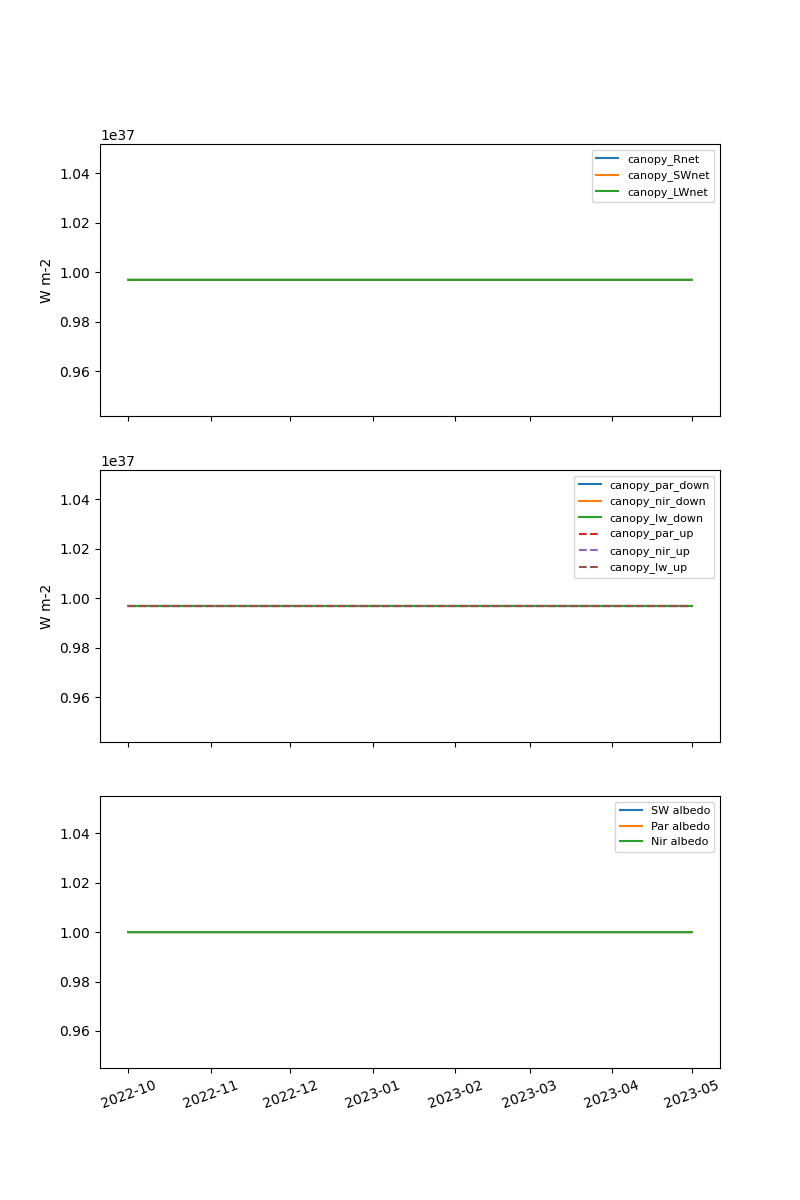

In [10]:
# net radiation components at canopy top
var = ['canopy_Rnet','canopy_SWnet', 'canopy_LWnet']
profs = ['canopy_par_down', 'canopy_par_up', 'canopy_nir_down','canopy_nir_up','canopy_lw_down','canopy_lw_up']

fig, ax = plt.subplots(3, 1, figsize=(8,12), sharex=True)

for v in var:
    ax[0].plot(t, results[v][:, sim], label=v)
ax[0].set_ylabel('W m-2')
ax[0].tick_params(axis='x', labelrotation = 20)
ax[0].legend(fontsize=8)    

# lets plot also partitioning of canopy_SWnet and canopy_LWnet.
# -1 is the index of uppermost gridpoint

for v in ['canopy_par_down', 'canopy_nir_down','canopy_lw_down']: # downward
    ax[1].plot(t, results[v][:,sim,-1], '-', label=v)
for v in ['canopy_par_up', 'canopy_nir_up','canopy_lw_up']: # upward
    ax[1].plot(t, results[v][:,sim,-1], '--', label=v)
ax[1].set_ylabel('W m-2')
ax[1].tick_params(axis='x', labelrotation = 20)
ax[1].legend(fontsize=8)

# canopy albedo
eps = 1e-16

# fraction of par on total SW
f_par = results['canopy_par_down'][:,sim,-1] / (results['canopy_par_down'][:,sim,-1] + results['canopy_nir_down'][:,sim,-1] + eps)

alb_par = results['canopy_par_up'][:,sim,-1] / (results['canopy_par_down'][:,sim,-1] + eps)
alb_nir = results['canopy_nir_up'][:,sim,-1] / (results['canopy_nir_down'][:,sim,-1] + eps)
alb_sw = f_par * alb_par + (1 - f_par) * alb_nir
alb_sw = np.maximum(0, np.minimum(1.0, alb_sw))

ax[2].plot(t, alb_sw, '-', label='SW albedo')
ax[2].plot(t, alb_par, '-', label='Par albedo')
ax[2].plot(t, alb_nir, '-', label='Nir albedo')

ax[2].tick_params(axis='x', labelrotation = 20)
ax[2].legend(fontsize=8)